# Orientation Effects & Attention Distribution Pipeline

This notebook investigates how Multimodal Large Language Models (MLLMs) allocate attention and handle spatial transformations. It evaluates model robustness against geometric perturbations and uses an automated scoring system to track how orientation shifts impact visual reasoning.

### 🎯 Core Objectives
- **Geometric Image Perturbation:** Automatically processes and horizontally flips images (e.g., generating the `flip_Inverted` corpus) to test if visual reasoning is biased by reading direction or standard spatial orientation.
- **Automated MLLM Inference:** Executes batch inference on the transformed visual datasets using models like `gemini-2.0-flash-001` via API endpoints to gather altered predictions.
- **LLM-as-a-Judge Evaluation Engine:** Employs an advanced reasoning model (e.g., DeepSeek) with dynamic, few-shot prompting to automatically evaluate and grade the predictions. It parses complex, multi-item ground-truth labels and assigns binary correctness arrays (e.g., `(1, 0, 1)`).
- **Data Alignment & Merging:** Cross-references the newly generated inference files with baseline predictions (e.g., outputting `flip_Inverted_merge.json`) to accurately measure the performance delta caused by the spatial disruptions.

### 📁 Input / Output
* **Inputs:** Baseline image directories, standard ground-truth label dictionaries, and raw text-prediction outputs.
* **Outputs:** Augmented/flipped image directories, raw spatial inference files (`infer.json`), and merged evaluation scores used to quantify the orientation effects.

In [33]:
infer={}

with open("flip_Inverted/infer.json", 'r', encoding='utf-8') as f:
    infer = json.load(f)

# # print(gem2label)
# print(str(infer2)[:100])
# print(infer2['0081-2015'])
merged_dict = {}
for key in gem1label:
    if key in infer:
        merged_dict[key] = [gem1label[key], infer[key]]

# Save the merged dictionary as a JSON file
with open('flip_Inverted_merge.json', 'w',encoding='utf-8') as f:
    json.dump(merged_dict, f, indent=1)

In [32]:
import os
import base64
import json
from openai import OpenAI

# prompt1 = """
# Answer the questions for each part of the merged image. There are exactly 6 separate images in this composite, and I need exactly 6 answers - no more, no less.

# Your response must follow this exact format:
# 1st image: [answer for image 1]
# 2nd image: [answer for image 2]
# 3rd image: [answer for image 3]
# 4th image: [answer for image 4]
# 5th image: [answer for image 5]
# 6th image: [answer for image 6]

# Example of the expected format:
# 1st image: 'Adele'
# 2nd image: 'Rat Race'
# 3rd image: 'brainstorm'
# 4th image: 'apple pie'
# 5th image: 'believe'
# 6th image: 'ironman'

# Important: Provide exactly 6 answers corresponding to the 6 images.
# """

prompt=""" 
 Give a brief, direct answer to the question in the image.

Examples:
    If asked "Which celebrity?" and the image shows Adele, 
    output: "Adele"
    If asked "Guess idiom" and the image depicts "when pigs fly," 
    output:"when pigs fly"
"""

def process_images(folder_path):
    # Create an OpenAI client with DeepInfra token and endpoint
    client = OpenAI(
        api_key="xxx",
        base_url="https://api.deepinfra.com/v1/openai",
    )
    
    output_file = os.path.join(folder_path, 'infer.json')

    if os.path.exists(output_file):
        with open(output_file, 'r', encoding='utf-8') as f:
            results = json.load(f)
    else:
        results = {}
    
    valid_extensions = ('.jpg', '.jpeg', '.png')
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_extensions)]
    
    for img_file in image_files:
        key = os.path.splitext(img_file)[0]
        
        # Skip if already processed
        if key in results:
            print(f"Skipping {img_file} - already processed")
            continue
            
        img_path = os.path.join(folder_path, img_file)
        
        try:
            # Read and encode image with proper data URI format
            with open(img_path, 'rb') as f:
                img_base = base64.b64encode(f.read()).decode('utf-8')
                # Add the appropriate data URI prefix based on file extension
                if img_file.lower().endswith(('.jpg', '.jpeg')):
                    img_base = f"data:image/jpeg;base64,{img_base}"
                elif img_file.lower().endswith('.png'):
                    img_base = f"data:image/png;base64,{img_base}"
            
            # Create a chat completion with the image
            completion = client.chat.completions.create(
                model="google/gemini-2.0-flash-001",
                messages=[
                    {"role": "system", "content": "You are a helpful assistant."},
                    {"role": "user", "content": [
                        {"type": "image_url", "image_url": {"url": img_base}},
                        {"type": "text", "text":prompt}
                    ]}
                ]
            )
            
            value = completion.choices[0].message.content
            results[key] = value
            print(key, '|', value)
     
            with open(output_file, 'w', encoding='utf-8') as f:
                json.dump(results, f, ensure_ascii=False, indent=2)
            
        except Exception as e:
            print(f"Error processing {img_file}: {str(e)}")
            results[key] = "Error: " + str(e)
            # Save results even if there's an error
            with open(output_file, 'w', encoding='utf-8') as f:
                json.dump(results, f, ensure_ascii=False, indent=2)
    
    return output_file

# Usage
folder_path = "flip_Inverted"
output_file = process_images(folder_path)
print(f"Results saved to: {output_file}")

0081 | Billie Eilish
0130 | Bruno Mars
0180 | Cristiano Ronaldo
0214 | Donald Trump
0222 | The Rock
0453 | Katy Perry
0507 | Lionel Messi
0570 | Marshmello, Usher, America (Erica)

0613 | Eminem
0719 | Rafael Nadal
0744 | Robert Downey Jr.
0839 | Motley Crew
0847 | Tiger Woods
0860 | Tom Cruise
0895 | Tyler Perry
0945 | Donald Trump
0965 | Red Hot Chili Peppers
1025 | Guess the mime.

1026 | Black Clover
1027 | Blue Lock.
1028 | "Hotel Transylvania"
1029 | Chainsaw Man
1030 | Gun, Ranger, Rocket, Galaxy = Guardians of the Galaxy
1031 | Guess The Meme
1032 | Detective Conan
1034 | Dr. Stone
1035 | dragon ball super
1036 | Upside down
1037 | Tinker Bell Tail.
1038 | Fireman Sam
1039 | Upside-Down, Mech, Pay Respects.

Naruto
1040 | Diet, app, knife, drop. 
Guess the movie: "Eat, Pray, Love"
1041 | Haikyu!!
1043 | "EMINƎM"
1044 | My Hero Academy
1045 | No Game No Life
1046 | Gintama
1047 | Video Game
1049 | Spirited Away
1050 | The X-Men
1051 | Sword Art Online
1052 | Shield Raccoon Chick

## Prompts

In [14]:
prompt2 = """
# MLLM Inference Evaluation Task

You will be given an input containing two items:
1. A list with 2 reference answers (ground truth labels)
2. A string containing an MLLM's inference (predicted answers)

Your task is to assess the correctness of the MLLM's inference by comparing it to the reference labels. For each label:
- Assign 1 if the inference is correct (matches the reference)
- Assign 0 if the inference is incorrect (doesn't match the reference)

Return your assessment as a binary tuple containing 2 numbers (one for each label).

## Examples:

**Input:** [["BILL GATES","Driver License"],"1st image:'Bill Gates'\n2nd image:'Drivers License'\n"]

**Output:**
Analysis:
- The MLLM predicted "Bill Gates" which is an exact match with the label (ignoring case) → correct (1)
- The MLLM predicted "Drivers License", which is a close match to the label "Driver License" → correct (1)
result:(1,1)

**Input:** [["spring chicken","stabbed in the back"],"1st image:'chicken legs'\n2nd image:'back stab'"]

**Output:**
Analysis:
- The MLLM predicted "chicken legs", which does not match the label "spring chicken" → incorrect (0)
- The MLLM predicted "back stab", which conveys the same meaning as "stabbed in the back" → correct (1)
result:(0,1)

**Input:** [["Dwayne Johnson;The Rock","storm in a teacup"],"1st image:'Dwayne Johnson a.k.a. The Rock'\n2nd image:'Storm in a Teacup'"]

**Output:**
Analysis:
- The MLLM predicted "Dwayne Johnson a.k.a. The Rock", which conveys the same meaning as the label → correct (1)
- The MLLM predicted "Storm in a Teacup", which is an exact match with the label (ignoring capitalization) → correct (1)
result:(1,1)

Now evaluate the following:
**Input:**
{}
"""

prompt1 ="""

# MLLM Inference Evaluation Task

You will be given an input containing two items:
1. A list with 1 reference answer (ground truth label)
2. A string containing an MLLM's inference (predicted answer)

Your task is to assess the correctness of the MLLM's inference by comparing it to the reference label:
- Assign 1 if the inference is correct (matches the reference)
- Assign 0 if the inference is incorrect (doesn't match the reference)

Return your assessment as a single binary value (0 or 1).

## Examples:

**Input:** [["BILL GATES"],"Bill Gates"]

**Output:**
Analysis:
- The MLLM predicted "Bill Gates" which is an exact match with the label (ignoring case) → correct (1)
result:(1)

**Input:** [["spring chicken"],"chicken legs"]

**Output:**
Analysis:
- The MLLM predicted "chicken legs", which does not match the label "spring chicken" → incorrect (0)
result:(0)

**Input:** [["Dwayne Johnson;The Rock"],"Dwayne Johnson a.k.a. The Rock"]

**Output:**
Analysis:
- The MLLM predicted "Dwayne Johnson a.k.a. The Rock", which conveys the same meaning as the label → correct (1)
result:(1)


**Input:** [["Super mario"],"The Super Mario Bros. Movie"]
**Output:**
Analysis:
- The MLLM predicted "The Super Mario Bros. Movie", which is semantically equivalent to the label "Super mario"  → correct (1)
result:(1)


Now evaluate the following:
**Input:**
{}

"""

prompt4 = """
You will be given an input containing two items:
1. A list with 4 labels (reference answers)
2. A string containing an MLLM's inference (predicted answers)

Your task is to assess the correctness of the MLLM's inference by comparing it to the reference labels. For each label:
- Assign 1 if the inference is correct (matches the reference)
- Assign 0 if the inference is incorrect (doesn't match the reference)

Return your assessment as a binary tuple containing 4 numbers (one for each label).

Examples:

Input:
[["BILL GATES","Driver License","spring chicken","stab in the back"],
"1st image:'Bill Gates'\n2nd image:'Drivers License'\n3d image:'chicken legs'\n4th image:'stabbed in the back'"]

Output:
Analysis:
- The MLLM predicted "Bill Gates" exact match with the label → correct (1)
- The MLLM predicted "Drivers License", which is a close match (the label is "Driver License") → correct (1)
- The MLLM predicted "chicken legs",which is incorrect according to the corresponding label  → incorrect (0)
- The MLLM predicted "backstabbed" ,which means the same meaning with "stab in the back" → correct (1)
result:(1,1,0,1)


Now evaluate the following:
Input:
{}
"""

prompt5 = """
You will be given an input containing two items:
1. A list with 5 labels (reference answers)
2. A string containing an MLLM's inference (predicted answers)

Your task is to assess the correctness of the MLLM's inference by comparing it to the reference labels. For each label:
- Assign 1 if the inference is correct (matches the reference)
- Assign 0 if the inference is incorrect (doesn't match the reference)

Return your assessment as a binary tuple containing 5 numbers (one for each label).

Examples:

Input:
[["BILL GATES","Driver License","spring chicken","stab in the back","butterfly"],
"1st image:'Bill Gates'\n2nd image:'Drivers License'\n3d image:'chicken legs'\n4th image:'stabbed in the back'\n5th image:'Butter Fly'"]

Output:
Analysis:
- The MLLM predicted "Bill Gates" exact match with the label → correct (1)
- The MLLM predicted "Drivers License", which is a close match (the label is "Driver License") → correct (1)
- The MLLM predicted "chicken legs",which is incorrect according to the corresponding label  → incorrect (0)
- The MLLM predicted "backstabbed" ,which means the same meaning with "stab in the back" → correct (1)
- The MLLM predicted "Butter Fly", almost same with the label(butterfly) → correct (1)
result:(1,1,0,1,1)


Now evaluate the following:
Input:
{}
"""

prompt6 = """
You will be given an input containing two items:
1. A list with 6 labels (reference answers)
2. A string containing an MLLM's inference (predicted answers)

Your task is to assess the correctness of the MLLM's inference by comparing it to the reference labels. For each label:
- Assign 1 if the inference is correct (matches the reference)
- Assign 0 if the inference is incorrect (doesn't match the reference)

Return your assessment as a binary tuple containing 6 numbers (one for each label).

Examples:

Input:
[["BILL GATES","Driver License","spring chicken","stab in the back","butterfly","Super mario"],
"1st image:'Bill Gates'\n2nd image:'Drivers License'\n3d image:'chicken legs'\n4th image:'stabbed in the back'\n5th image:'Butter Fly'\n6th image: Super Mario Bros "]

Output:
Analysis:
- The MLLM predicted "Bill Gates" exact match with the label → correct (1)
- The MLLM predicted "Drivers License", which is a close match (the label is "Driver License") → correct (1)
- The MLLM predicted "chicken legs",which is incorrect according to the corresponding label  → incorrect (0)
- The MLLM predicted "backstabbed" ,which means the same meaning with "stab in the back" → correct (1)
- The MLLM predicted "Butter Fly", almost same with the label(butterfly) → correct (1)
- The MLLM predicted "Super Mario Bros", which is the same concept with "Super mario" → correct (1)
result:(1,1,0,1,1,1)


Now evaluate the following:
Input:
{}
"""

prompt3 = """
You will be given an input containing two items:
1. A list with 3 labels (reference answers)
2. A string containing an MLLM's inference (predicted answers)

Your task is to assess the correctness of the MLLM's inference by comparing it to the reference labels. For each label:
- Assign 1 if the inference is correct (matches the reference)
- Assign 0 if the inference is incorrect (doesn't match the reference)

Return your assessment as a binary tuple containing 3 numbers (one for each label).

Examples:

Input:
[["BILL GATES","Driver License","spring chicken"],"1st image:'Bill Gates'\n2nd image:'Drivers License'\n3d image:'chicken legs'"]

Output:
Analysis:
- The MLLM predicted "Bill Gates" exact match with the label → correct (1)
- The MLLM predicted "Drivers License", which is a close match (the label is "Driver License") → correct (1)
- The MLLM predicted "chicken legs",which is incorrect according to the corresponding label  → incorrect (0)
result:(1,1,0)


Now evaluate the following:
Input:
{}
"""

## Inference Evaluation

### Deepseek

In [34]:
import json
from openai import OpenAI

# Create an OpenAI client with DeepSeek API key and endpoint
client = OpenAI(
    api_key="xxx",
    base_url="https://api.deepseek.com"
)

results_dict = {}

# Prompt template for evaluating answers


# Process each entry in the dictionary
for key, value in merged_dict.items():
    print(f"Processing {key}...")
    if key in results_dict:
        continue
    # Create the input for the API
    input_for_evaluation = str(value)
    prompt = prompt1.format(input_for_evaluation)
    
    # Call the DeepSeek API
    try:
        response = client.chat.completions.create(
            model="deepseek-chat",
            messages=[
                {"role": "system", "content": "You are a helpful assistant"},
                {"role": "user", "content": prompt}
            ],
            stream=False
        )
        
        # Extract the evaluation result
        evaluation_result = response.choices[0].message.content.strip()
        print(f"{key}: {evaluation_result}")
        
        # Store the result
        results_dict[key] = evaluation_result
        
    except Exception as e:
        print(f"Error processing {key}: {e}")
        results_dict[key] = "Error: " + str(e)

# Save the results to a JSON file
    with open("flip_Inverted_evaluation_results.json", "w", encoding='utf-8') as f:
        json.dump(results_dict, f, indent=2)

# print("Evaluation complete. Results saved to evaluation_results.json")

Processing 0081...
0081: Analysis:
- The MLLM predicted "Billie Eilish", which does not match the label "BILL GATES" → incorrect (0)
result:(0)
Processing 0130...
0130: Analysis:
- The MLLM predicted "Bruno Mars", which is an exact match with the label "Bruno Mars" → correct (1)
result:(1)
Processing 0180...
0180: Analysis:
- The MLLM predicted "Cristiano Ronaldo", which is an exact match with the label "Cristiano Ronaldo" → correct (1)
result:(1)
Processing 0214...
0214: Analysis:
- The MLLM predicted "Donald Trump", which is an exact match with the label "Donald Trump" → correct (1)
result:(1)
Processing 0222...
0222: Analysis:
- The MLLM predicted "The Rock", which is one of the names listed in the reference label "Dwayne Johnson;The Rock". Since the prediction matches one of the names in the reference, it is considered correct → correct (1)
result:(1)
Processing 0453...
0453: Analysis:
- The MLLM predicted "Katy Perry", which is an exact match with the label "Katy Perry" → correct 

### Claude

In [76]:
import json
import re

# Input data
# data = {
#   "0081-2015": "Output:\n( 0 , 1 )\n\nExplanation:\n- The MLLM predicted \"Bill Murray\" instead of \"BILL GATES\" \u2192 incorrect (0)\n- The MLLM predicted \"Stabbed in the back\" which matches \"stab in the back\" in meaning \u2192 correct (1)",
#   "0130-2016": "Output:\n( 1,1 )\n\nExplanation:\n- The MLLM predicted \"Bruno Mars\" which matches exactly with the reference label \"Bruno Mars\" \u2192 correct (1)\n- The MLLM predicted \"Stealing thunder\" which matches the meaning of \"steal someone's thunder\" \u2192 correct (1)",
#   "0180-2018": "Output:\n(1 ,1)\n\nExplanation:\n- The MLLM predicted \"Cristiano Ronaldo\" which matches exactly with the reference label \"Cristiano Ronaldo\" \u2192 correct (1)\n- The MLLM predicted \"Storm in a teacup\" which matches exactly with the reference label \"storm in a teacup\" \u2192 correct (1)",
#   "0214-2019": "Output:\n( 1, 1)\n\nExplanation:\n- The MLLM predicted \"Donald Trump\" which matches exactly \u2192 correct (1)\n- The MLLM predicted \"Tempest in a teapot\" which is a close synonym of \"storm in a teacup\" and matches in meaning \u2192 correct (1)"
# }
data={}

with open("evaluation_results6.json", 'r', encoding='utf-8') as f:
    data = json.load(f)


result = {}

# Process each entry
for key, value in data.items():
    # Use regex to find the tuple pattern in the string
   # match = re.search(r'\(\s*(\d)\s*,\s*(\d)\s*\,\s*(\d)\s*\,\s*(\d)\s*\)', value)
    # match = re.search(r'\(\s*(\d)\s*,\s*(\d)\s*\,\s*(\d)\s*\)', value)
    # match = re.search(r'\(\s*(\d)\s*,\s*(\d)\s*\)', value)
    # match = re.search(r'\(\s*(\d)\s*,\s*(\d)\s*\,\s*(\d)\s*\,\s*(\d)\s*\,\s*(\d)\s*\)', value)
    match = re.search(r'\(\s*(\d)\s*,\s*(\d)\s*\,\s*(\d)\s*\,\s*(\d)\s*\,\s*(\d)\s*\,\s*(\d)\s*\)', value)
    if match:
        # Extract the two numbers and convert to integers
        first_number = int(match.group(1))
        second_number = int(match.group(2))
        third_number = int(match.group(3))
        forth_number = int(match.group(4))
        fifth_number = int(match.group(5))
        sixth_number = int(match.group(6))
        # Add the tuple to the result dictionary
        result[key] = (first_number, second_number, third_number,forth_number,fifth_number,sixth_number)

# Save the result to a JSON file
with open('final.json', 'w') as f:
    # Use a custom serializer to handle tuples
    json.dump(result, f, default=lambda x: list(x) if isinstance(x, tuple) else x)

# print("Extraction complete. Result saved to final3.json")

In [78]:
def add_tuples_from_dict(input_dict):
    # Initialize result with zeros for each position
    result = [0, 0, 0, 0, 0, 0]
    
    # Iterate through each tuple in the dictionary values
    for tuple_value in input_dict.values():
        # Add each element of the tuple to the corresponding position in result
        for i in range(len(tuple_value)):
            result[i] += tuple_value[i]
    
    return result



res = add_tuples_from_dict(result)
print(res)  # Output: [3, 3, 4]
print(sum(res))

[121, 104, 87, 87, 83, 80]
562


<b>Number of images:</b><br>
[645,613,605,582,576,562\](870)<br>
[0.7413793103448276, 0.7045977011494253, 0.6954022988505747, 0.6689655172413793, 0.6635944700460829, 0.6459770114942529\]
<ul>
    <li><b>2:</b>  [336, 277](435)</li>
    <li><b>3:</b>  [234, 189, 182](290)</li>
    <li><b>4:</b>  [177, 148, 138, 119](217)</li>
    <li><b>5:</b>  [141, 111, 113, 104, 107](174)</li>
    <li><b>6:</b>  [121, 104, 87, 87, 83, 80](145)</li>
</ul>




<table>
    <tr>
        <th>Transform</th>
        <th class="header">Original</th>
        <th class="header">Mirrored</th>
    </tr>
    <tr>
        <td class="category">None</td>
        <td>645/870</td>
        <td>338/870</td>
    </tr>
    <tr>
        <td class="category">Left</td>
        <td>432/870</td>
        <td>300/870</td>
    </tr>
    <tr>
        <td class="category">Right</td>
        <td>515/870</td>
        <td>220/870</td>
    </tr>
    <tr>
        <td class="category">Inverted</td>
        <td>373/870</td>
        <td>339/870</td>
    </tr>
</table>

# Visualization

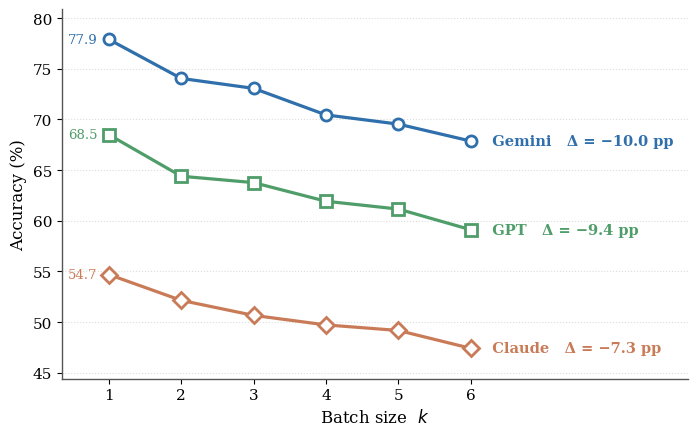

In [78]:
"""
Probe I, Fig. (a) — Aggregate accuracy vs. batch size k.
Replaces fig/left.png with three probe models (Gemini, GPT, Claude).
"""

import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------------------------
# Style: publication-quality defaults
# ---------------------------------------------------------------------------
plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         11,
    'axes.labelsize':    12,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'axes.linewidth':    1.0,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'pdf.fonttype':      42,   # editable text in PDF
    'ps.fonttype':       42,
})

# ---------------------------------------------------------------------------
# Data
# ---------------------------------------------------------------------------
k = np.arange(1, 7)

import numpy as np

data = {
    'Gemini': np.array([77.90, 74.05, 73.07, 70.45, 69.54, 67.87]),
    'GPT':    np.array([68.50, 64.40, 63.77, 61.93, 61.16, 59.12]),
    'Claude': np.array([54.70, 52.15, 50.67, 49.73, 49.18, 47.42]),
}
# Calm, distinguishable, print-friendly palette
colors  = {'Gemini': '#2F6FAB', 'GPT': '#4F9D69', 'Claude': '#C97B57'}
markers = {'Gemini': 'o',       'GPT': 's',       'Claude': 'D'}

# ---------------------------------------------------------------------------
# Figure
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.2, 4.5))

for name, y in data.items():
    ax.plot(k, y,
            color=colors[name], marker=markers[name],
            markersize=8, markerfacecolor='white', markeredgewidth=2.0,
            linewidth=2.3, zorder=3, label=name)

# Right-edge direct labels: model name + total drop
for name, y in data.items():
    delta = y[0] - y[-1]
    ax.annotate(f"  {name}   Δ = −{delta:.1f} pp",
                xy=(k[-1], y[-1]),
                xytext=(8, 0), textcoords='offset points',
                va='center', fontsize=10.5,
                color=colors[name], fontweight='bold')

# Left-edge baseline values (k = 1)
for name, y in data.items():
    ax.annotate(f"{y[0]:.1f}",
                xy=(k[0], y[0]),
                xytext=(-8, 0), textcoords='offset points',
                va='center', ha='right',
                fontsize=9.5, color=colors[name])

# Axes
ax.set_xlabel('Batch size  $k$')
ax.set_ylabel('Accuracy (%)')
ax.set_xticks(k)
ax.set_xlim(0.35, 9.0)

y_lo = min(d.min() for d in data.values()) - 3
y_hi = max(d.max() for d in data.values()) + 3
ax.set_ylim(y_lo, y_hi)

# Grid + spines
ax.grid(True, axis='y', linestyle=':', alpha=0.45, zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#555555')
ax.spines['bottom'].set_color('#555555')

plt.tight_layout()
plt.savefig('batch_accuracy.pdf')
plt.savefig('batch_accuracy.png', dpi=300)
plt.show()

In [10]:
gemini = [
    [0.779],
    [0.8116, 0.6691],
    [0.8478, 0.6848, 0.6594],
    [0.8571, 0.7166, 0.6681, 0.5762],
    [0.8514, 0.6703, 0.6823, 0.628, 0.6461],
    [0.8768, 0.7536, 0.6304, 0.6304, 0.6014, 0.5797]
]

GPT = [
    [0.6847],
    [0.7109, 0.5767],
    [0.7334, 0.6044, 0.576],
    [0.7505, 0.62, 0.5965, 0.5101],
    [0.7481, 0.5902, 0.5923, 0.5541, 0.5738],
    [0.7612, 0.6531, 0.5545, 0.5462, 0.527, 0.505]
]

Claude = [
    [0.5471],
    [0.5644, 0.4787],
    [0.5969, 0.4724, 0.4506],
    [0.5871, 0.518, 0.4766, 0.4071],
    [0.5995, 0.4805, 0.4679, 0.4484, 0.4627],
    [0.6082, 0.5364, 0.4379, 0.447, 0.416, 0.3996]
]

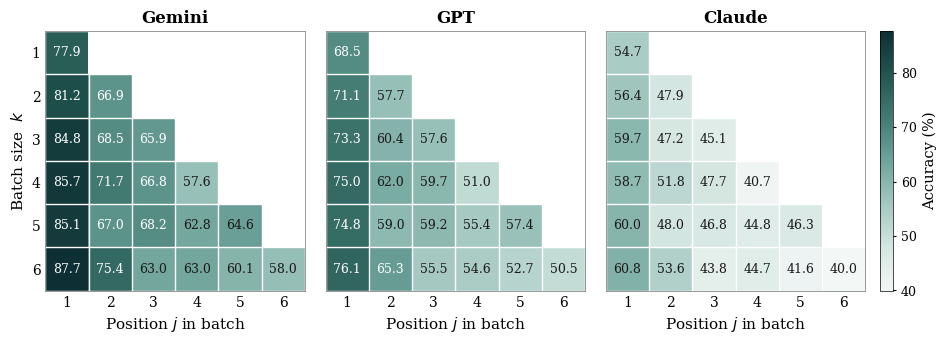

In [21]:
"""
Probe I — Position-wise accuracy heatmaps for three probe models.
Triangular layout: row k = batch size, column j = item position within batch.
"""

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, Normalize

# ---------------------------------------------------------------------------
# Publication style
# ---------------------------------------------------------------------------
plt.rcParams.update({
    'font.family':     'serif',
    'font.size':        11,
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
    'axes.linewidth':   0.8,
    'savefig.dpi':      300,
    'savefig.bbox':     'tight',
    'pdf.fonttype':     42,
    'ps.fonttype':      42,
})

# ---------------------------------------------------------------------------
# Data
# ---------------------------------------------------------------------------
gemini = [
    [0.779],
    [0.8116, 0.6691],
    [0.8478, 0.6848, 0.6594],
    [0.8571, 0.7166, 0.6681, 0.5762],
    [0.8514, 0.6703, 0.6823, 0.6280, 0.6461],
    [0.8768, 0.7536, 0.6304, 0.6304, 0.6014, 0.5797],
]
gpt = [
    [0.6847],
    [0.7109, 0.5767],
    [0.7334, 0.6044, 0.5760],
    [0.7505, 0.6200, 0.5965, 0.5101],
    [0.7481, 0.5902, 0.5923, 0.5541, 0.5738],
    [0.7612, 0.6531, 0.5545, 0.5462, 0.5270, 0.5050],
]
claude = [
    [0.5471],
    [0.5644, 0.4787],
    [0.5969, 0.4724, 0.4506],
    [0.5871, 0.5180, 0.4766, 0.4071],
    [0.5995, 0.4805, 0.4679, 0.4484, 0.4627],
    [0.6082, 0.5364, 0.4379, 0.4470, 0.4160, 0.3996],
]

def to_matrix(rows, N=6):
    M = np.full((N, N), np.nan)
    for i, row in enumerate(rows):
        for j, v in enumerate(row):
            M[i, j] = 100.0 * v
    return M

models = [
    ('Gemini', to_matrix(gemini)),
    ('GPT',    to_matrix(gpt)),
    ('Claude', to_matrix(claude)),
]

# Shared color scale
finite = np.concatenate([m[~np.isnan(m)] for _, m in models])
vmin, vmax = float(finite.min()), float(finite.max())
norm = Normalize(vmin=vmin, vmax=vmax)

# ---------------------------------------------------------------------------
# Custom elegant sequential colormap (muted teal → deep slate)
# ---------------------------------------------------------------------------
cmap = LinearSegmentedColormap.from_list(
    'paper_seq',
    ['#f3f7f6', '#d4e6e1', '#a3c8c0', '#6ea49b',
     '#427a72', '#22564f', '#0e2f33'],
    N=256,
)

cmap.set_bad(color='white', alpha=0.0)   # NaN cells render as background

def text_color(val):
    """Black text on light cells, white on dark — based on perceived luminance."""
    r, g, b, _ = cmap(norm(val))
    return 'white' if (0.299*r + 0.587*g + 0.114*b) < 0.55 else '#1a1a1a'

# ---------------------------------------------------------------------------
# Figure
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(10.0, 3.7), sharey=True)
fig.subplots_adjust(left=0.06, right=0.88, top=0.90, bottom=0.16, wspace=0.08)

im = None
for ax, (name, M) in zip(axes, models):
    n = M.shape[0]
    im = ax.imshow(M, cmap=cmap, norm=norm, aspect='equal')

    # Cell annotations
    for i in range(n):
        for j in range(n):
            v = M[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.1f}',
                        ha='center', va='center',
                        fontsize=9, color=text_color(v))

    # Major ticks at cell centres
    ax.set_xticks(range(n));   ax.set_yticks(range(n))
    ax.set_xticklabels(range(1, n+1))
    ax.set_yticklabels(range(1, n+1))

    # Minor ticks → white grid lines between cells
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=1.0)
    ax.tick_params(which='both', length=0)

    ax.set_title(name, fontsize=12, pad=6, fontweight='bold')
    ax.set_xlabel('Position $j$ in batch')

    for spine in ax.spines.values():
        spine.set_color('#888888')
        spine.set_linewidth(0.6)

axes[0].set_ylabel('Batch size  $k$')

# ---------------------------------------------------------------------------
# Shared colorbar — fits the actual axes height under aspect='equal'
# ---------------------------------------------------------------------------
fig.canvas.draw()                          # finalise positions after aspect lock
pos = axes[-1].get_position()
cbar_ax = fig.add_axes([0.895, pos.y0, 0.013, pos.height])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Accuracy (%)', fontsize=10.5)
cbar.outline.set_linewidth(0.5)
cbar.ax.tick_params(labelsize=9, length=2)

plt.savefig('position_heatmap.pdf')
plt.savefig('position_heatmap.png', dpi=300)
plt.show()

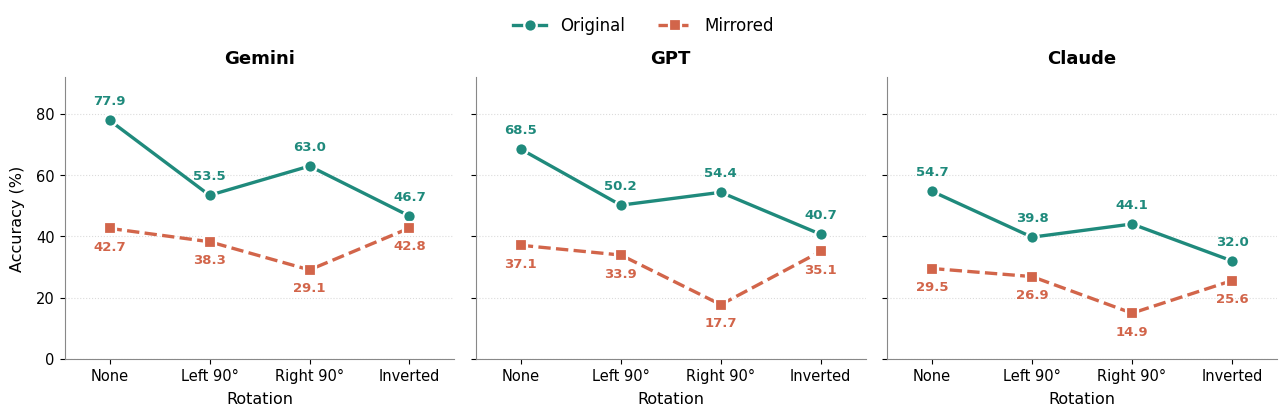

In [77]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Data
# ============================================================
transforms = ['None', 'Left 90°', 'Right 90°', 'Inverted']

gemini_original = [77.93793103448276, 53.4551724137931, 62.99540229885057, 46.673563218390804]
gemini_mirrored = [42.650574712643675, 38.282758620689656, 29.087356321839085, 42.76551724137931]

gpt_original    = [68.5161448467184, 50.228941324567806, 54.433016984159664, 40.698964174793325]
gpt_mirrored    = [37.12100616256181, 33.941322192084264, 17.733696436169485, 35.12645842089748]

claude_original = [54.7481547902219, 39.77451212987104, 44.07889546021887, 32.01542782831876]
claude_mirrored = [29.538770824307136, 26.89924632506344, 14.948951523202545, 25.58863620437925]

models = [
    ('Gemini', gemini_original, gemini_mirrored),
    ('GPT',    gpt_original,    gpt_mirrored),
    ('Claude', claude_original, claude_mirrored),
]

# ============================================================
# Style
# ============================================================
plt.rcParams.update({
    'font.family':     'DejaVu Sans',
    'font.size':       11,
    'axes.titlesize':  13,
    'axes.labelsize':  11.5,
    'xtick.labelsize': 10.5,
    'ytick.labelsize': 10.5,
})

COLOR_ORIG = '#1f8a7c'   # deep teal — paper-consistent "ground truth"
COLOR_MIRR = '#d2654a'   # muted terracotta — perturbation, earthy not loud

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)

# ============================================================
# Per-model panels
# ============================================================
for idx, (ax, (name, orig, mirr)) in enumerate(zip(axes, models)):
    x = np.arange(len(transforms))

    # Lines (markers separate so they sit on top of any crossing)
    ax.plot(x, orig, color=COLOR_ORIG, lw=2.4, zorder=2)
    ax.plot(x, mirr, color=COLOR_MIRR, lw=2.4, ls='--', zorder=2)
    ax.plot(x, orig, 'o', color=COLOR_ORIG, ms=9,
            mec='white', mew=1.6, zorder=4)
    ax.plot(x, mirr, 's', color=COLOR_MIRR, ms=8,
            mec='white', mew=1.6, zorder=4)

    # Numeric labels — Original above, Mirrored below
    for i, (o, m) in enumerate(zip(orig, mirr)):
        ax.annotate(f'{o:.1f}', (i, o),
                    xytext=(0, 11), textcoords='offset points',
                    ha='center', fontsize=9.5,
                    color=COLOR_ORIG, fontweight='semibold')
        ax.annotate(f'{m:.1f}', (i, m),
                    xytext=(0, -16), textcoords='offset points',
                    ha='center', fontsize=9.5,
                    color=COLOR_MIRR, fontweight='semibold')

    # Cosmetics
    ax.set_title(name, fontweight='bold', pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(transforms)
    ax.set_xlabel('Rotation', labelpad=6)
    ax.set_xlim(-0.45, 3.45)
    ax.set_ylim(0, 92)
    ax.grid(True, axis='y', linestyle=':', alpha=0.45, zorder=0)
    ax.set_axisbelow(True)

    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color('#888888')
        ax.spines[s].set_linewidth(0.8)

    if idx == 0:
        ax.set_ylabel('Accuracy (%)', labelpad=8)

# ============================================================
# Single shared legend at the top
# ============================================================
legend_handles = [
    plt.Line2D([], [], marker='o', color=COLOR_ORIG,
               lw=2.4, ms=9, mec='white', mew=1.6, label='Original'),
    plt.Line2D([], [], marker='s', color=COLOR_MIRR,
               lw=2.4, ls='--', ms=8, mec='white', mew=1.6, label='Mirrored'),
]
fig.legend(handles=legend_handles, loc='upper center', ncol=2,
           frameon=False, fontsize=12,
           bbox_to_anchor=(0.5, 1.005))

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('trans_3models.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Image Tranformation

In [28]:

import os
from PIL import Image

# Folder containing the images
input_folder = "flip"

# Create output folder if it doesn't exist
output_folder = "flip_right"
os.makedirs(output_folder, exist_ok=True)

# Get all files in the input folder
files = os.listdir(input_folder)

# Counter for processed images
processed = 0

# Process each file
for filename in files:
    try:
        # Check if the file is an image
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif', '.tiff')):
            # Open the image
            img_path = os.path.join(input_folder, filename)
            img = Image.open(img_path)
            
            # Rotate the image 90 degrees counterclockwise
            rotated_img = img.rotate(270, expand=True)
            
            # Save the rotated image
            output_path = os.path.join(output_folder, filename)
            rotated_img.save(output_path)
            
            processed += 1
            print(f"Rotated: {filename}")
    except Exception as e:
        print(f"Error processing {filename}: {e}")

print(f"Rotation complete! {processed} images processed.")


#change the above code , so that it would flips the image horizontally (left becomes right, and right becomes left)

Rotated: 0081.jpg
Rotated: 0130.jpg
Rotated: 0180.jpg
Rotated: 0214.jpg
Rotated: 0222.jpg
Rotated: 0453.jpg
Rotated: 0507.jpg
Rotated: 0570.jpg
Rotated: 0613.jpg
Rotated: 0719.jpg
Rotated: 0744.jpg
Rotated: 0839.jpg
Rotated: 0847.jpg
Rotated: 0860.jpg
Rotated: 0895.jpg
Rotated: 0945.jpg
Rotated: 0965.jpg
Rotated: 1025.jpg
Rotated: 1026.jpg
Rotated: 1027.jpg
Rotated: 1028.jpg
Rotated: 1029.jpg
Rotated: 1030.jpg
Rotated: 1031.jpg
Rotated: 1032.jpg
Rotated: 1034.jpg
Rotated: 1035.jpg
Rotated: 1036.jpg
Rotated: 1037.jpg
Rotated: 1038.jpg
Rotated: 1039.jpg
Rotated: 1040.jpg
Rotated: 1041.jpg
Rotated: 1043.jpg
Rotated: 1044.jpg
Rotated: 1045.jpg
Rotated: 1046.jpg
Rotated: 1047.jpg
Rotated: 1049.jpg
Rotated: 1050.jpg
Rotated: 1051.jpg
Rotated: 1052.jpg
Rotated: 1054.jpg
Rotated: 1055.jpg
Rotated: 1056.jpg
Rotated: 1057.jpg
Rotated: 1058.jpg
Rotated: 1059.jpg
Rotated: 1060.jpg
Rotated: 1062.jpg
Rotated: 1063.jpg
Rotated: 1066.jpg
Rotated: 1067.jpg
Rotated: 1069.jpg
Rotated: 1070.jpg
Rotated: 1

In [25]:
import os
from PIL import Image

# Folder containing the images
input_folder = "gem"

# Create output folder if it doesn't exist
output_folder = "flip"
os.makedirs(output_folder, exist_ok=True)

# Get all files in the input folder
files = os.listdir(input_folder)

# Counter for processed images
processed = 0

# Process each file
for filename in files:
    try:
        # Check if the file is an image
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif', '.tiff')):
            # Open the image
            img_path = os.path.join(input_folder, filename)
            img = Image.open(img_path)
            
            # Flip the image horizontally
            flipped_img = img.transpose(Image.FLIP_LEFT_RIGHT)
            
            # Save the flipped image
            output_path = os.path.join(output_folder, filename)
            flipped_img.save(output_path)
            
            processed += 1
            print(f"Flipped: {filename}")
    except Exception as e:
        print(f"Error processing {filename}: {e}")

print(f"Horizontal flipping complete! {processed} images processed.")

Flipped: 0081.jpg
Flipped: 0130.jpg
Flipped: 0180.jpg
Flipped: 0214.jpg
Flipped: 0222.jpg
Flipped: 0453.jpg
Flipped: 0507.jpg
Flipped: 0570.jpg
Flipped: 0613.jpg
Flipped: 0719.jpg
Flipped: 0744.jpg
Flipped: 0839.jpg
Flipped: 0847.jpg
Flipped: 0860.jpg
Flipped: 0895.jpg
Flipped: 0945.jpg
Flipped: 0965.jpg
Flipped: 1025.jpg
Flipped: 1026.jpg
Flipped: 1027.jpg
Flipped: 1028.jpg
Flipped: 1029.jpg
Flipped: 1030.jpg
Flipped: 1031.jpg
Flipped: 1032.jpg
Flipped: 1034.jpg
Flipped: 1035.jpg
Flipped: 1036.jpg
Flipped: 1037.jpg
Flipped: 1038.jpg
Flipped: 1039.jpg
Flipped: 1040.jpg
Flipped: 1041.jpg
Flipped: 1043.jpg
Flipped: 1044.jpg
Flipped: 1045.jpg
Flipped: 1046.jpg
Flipped: 1047.jpg
Flipped: 1049.jpg
Flipped: 1050.jpg
Flipped: 1051.jpg
Flipped: 1052.jpg
Flipped: 1054.jpg
Flipped: 1055.jpg
Flipped: 1056.jpg
Flipped: 1057.jpg
Flipped: 1058.jpg
Flipped: 1059.jpg
Flipped: 1060.jpg
Flipped: 1062.jpg
Flipped: 1063.jpg
Flipped: 1066.jpg
Flipped: 1067.jpg
Flipped: 1069.jpg
Flipped: 1070.jpg
Flipped: 1